# 🌍 Global Land Temperature Analysis — EDA, Machine Learning & Deep Learning

### Kaggle / Colab-ready portfolio project

**Pipeline:** Load → Clean → EDA Dashboard → Feature Engineering → Classical ML → LSTM Deep Learning → Evaluation → Forecasting

## 1. Import Required Libraries
This cell imports all libraries used for data processing, visualization, and machine learning.

In [2]:
import os
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def kpi(label, value, icon="📌"):
    return '<div style="display:inline-block;min-width:180px;padding:16px;margin:5px;border-radius:14px;background:#f8fafc;border:1px solid #e5e7eb"><div style="font-size:24px">'+str(icon)+'</div><div style="color:#64748b;font-size:12px">'+str(label)+'</div><div style="font-size:21px;font-weight:700">'+str(value)+'</div></div>'

print("✅ Libraries and visualization theme loaded")

✅ Libraries and visualization theme loaded


## 2. Kaggle Dataset Detection
This cell searches **only inside `/kaggle/input`** and identifies the correct CSV or ZIP file. It specifically prefers a file containing `GlobalLandTemperaturesByCity` in its name.

In [3]:
SEARCH_ROOTS = [Path("/kaggle/input"), Path("/content"), Path.cwd(), Path("/mnt/data")]
candidates = []
for root in SEARCH_ROOTS:
    if root.exists():
        try:
            candidates += [p for p in root.rglob("*") if p.is_file() and "globallandtemperaturesbycity" in p.name.lower() and p.suffix.lower() in {".csv", ".zip"}]
        except Exception:
            pass
candidates = list(dict.fromkeys(candidates))
if not candidates:
    raise FileNotFoundError("Upload GlobalLandTemperaturesByCity.csv or GlobalLandTemperaturesByCity.csv.zip before running this notebook.")

CSV_PATH = next((p for p in candidates if p.suffix.lower()==".csv"), None)
if CSV_PATH is None:
    ZIP_PATH = candidates[0]
    EXTRACT_DIR = Path.cwd() / "global_temperature_data"
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        members=[m for m in z.namelist() if m.lower().endswith('.csv')]
        member=next((m for m in members if 'globallandtemperaturesbycity' in Path(m).name.lower()), members[0])
        CSV_PATH=EXTRACT_DIR / Path(member).name
        if not CSV_PATH.exists():
            with z.open(member) as src, open(CSV_PATH,'wb') as dst:
                while True:
                    chunk=src.read(1024*1024)
                    if not chunk: break
                    dst.write(chunk)
print("✅ Dataset located:", CSV_PATH)

✅ Dataset located: /kaggle/input/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv


## 3. Load the Dataset
The date column `dt` is parsed as a datetime column. Basic validation confirms that all required columns exist.

In [4]:
required_columns = [
    "dt", "AverageTemperature", "AverageTemperatureUncertainty",
    "City", "Country", "Latitude", "Longitude"
]

df = pd.read_csv(CSV_PATH, parse_dates=["dt"])

missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("✅ Dataset loaded successfully")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head())

✅ Dataset loaded successfully
Rows: 8,599,212
Columns: 7


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


## 4. Initial Data Inspection
We examine the dataset size, date range, geographic coverage, and missing values.

In [5]:
print("Date range:", df["dt"].min().date(), "to", df["dt"].max().date())
print("Unique cities:", f"{df['City'].nunique():,}")
print("Unique countries:", df["Country"].nunique())

missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

display(missing)

Date range: 1743-11-01 to 2013-09-01
Unique cities: 3,448
Unique countries: 159


,Missing Values,Missing Percentage
AverageTemperature,364130,4.23
AverageTemperatureUncertainty,364130,4.23
dt,0,0.00
City,0,0.00
Country,0,0.00
Latitude,0,0.00
Longitude,0,0.00


## 5. Data Cleaning
Duplicate records are removed. Records without the target temperature are removed because they cannot be used for temperature analysis or prediction. Latitude and longitude are converted to decimal coordinates.

In [6]:
original_rows = len(df)

df = df.drop_duplicates().copy()
df = df.dropna(subset=["AverageTemperature"]).copy()

def coordinate_to_decimal(value):
    value = str(value).strip()
    try:
        number = float(value[:-1])
        direction = value[-1].upper()
        return -number if direction in ("S", "W") else number
    except Exception:
        return np.nan

df["LatitudeDecimal"] = df["Latitude"].apply(coordinate_to_decimal)
df["LongitudeDecimal"] = df["Longitude"].apply(coordinate_to_decimal)

print(f"Rows before cleaning: {original_rows:,}")
print(f"Rows after cleaning:  {len(df):,}")
print(f"Rows removed:         {original_rows-len(df):,}")

Rows before cleaning: 8,599,212
Rows after cleaning:  8,235,082
Rows removed:         364,130


## 6. Feature Engineering
We derive time features that support trend analysis and machine learning.

In [7]:
df["Year"] = df["dt"].dt.year
df["Month"] = df["dt"].dt.month
df["Decade"] = (df["Year"] // 10) * 10

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}
df["Season"] = df["Month"].map(season_map)

display(df[["dt", "Year", "Month", "Decade", "Season", "AverageTemperature"]].head())

,dt,Year,Month,Decade,Season,AverageTemperature
0,1743-11-01,1743,11,1740,Autumn,6.068
5,1744-04-01,1744,4,1740,Spring,5.788
6,1744-05-01,1744,5,1740,Spring,10.644
7,1744-06-01,1744,6,1740,Summer,14.051
8,1744-07-01,1744,7,1740,Summer,16.082


## 📊 EDA Dashboard

A single multi-panel dashboard gives a high-level view of distribution, trend, seasonality, coverage and uncertainty.

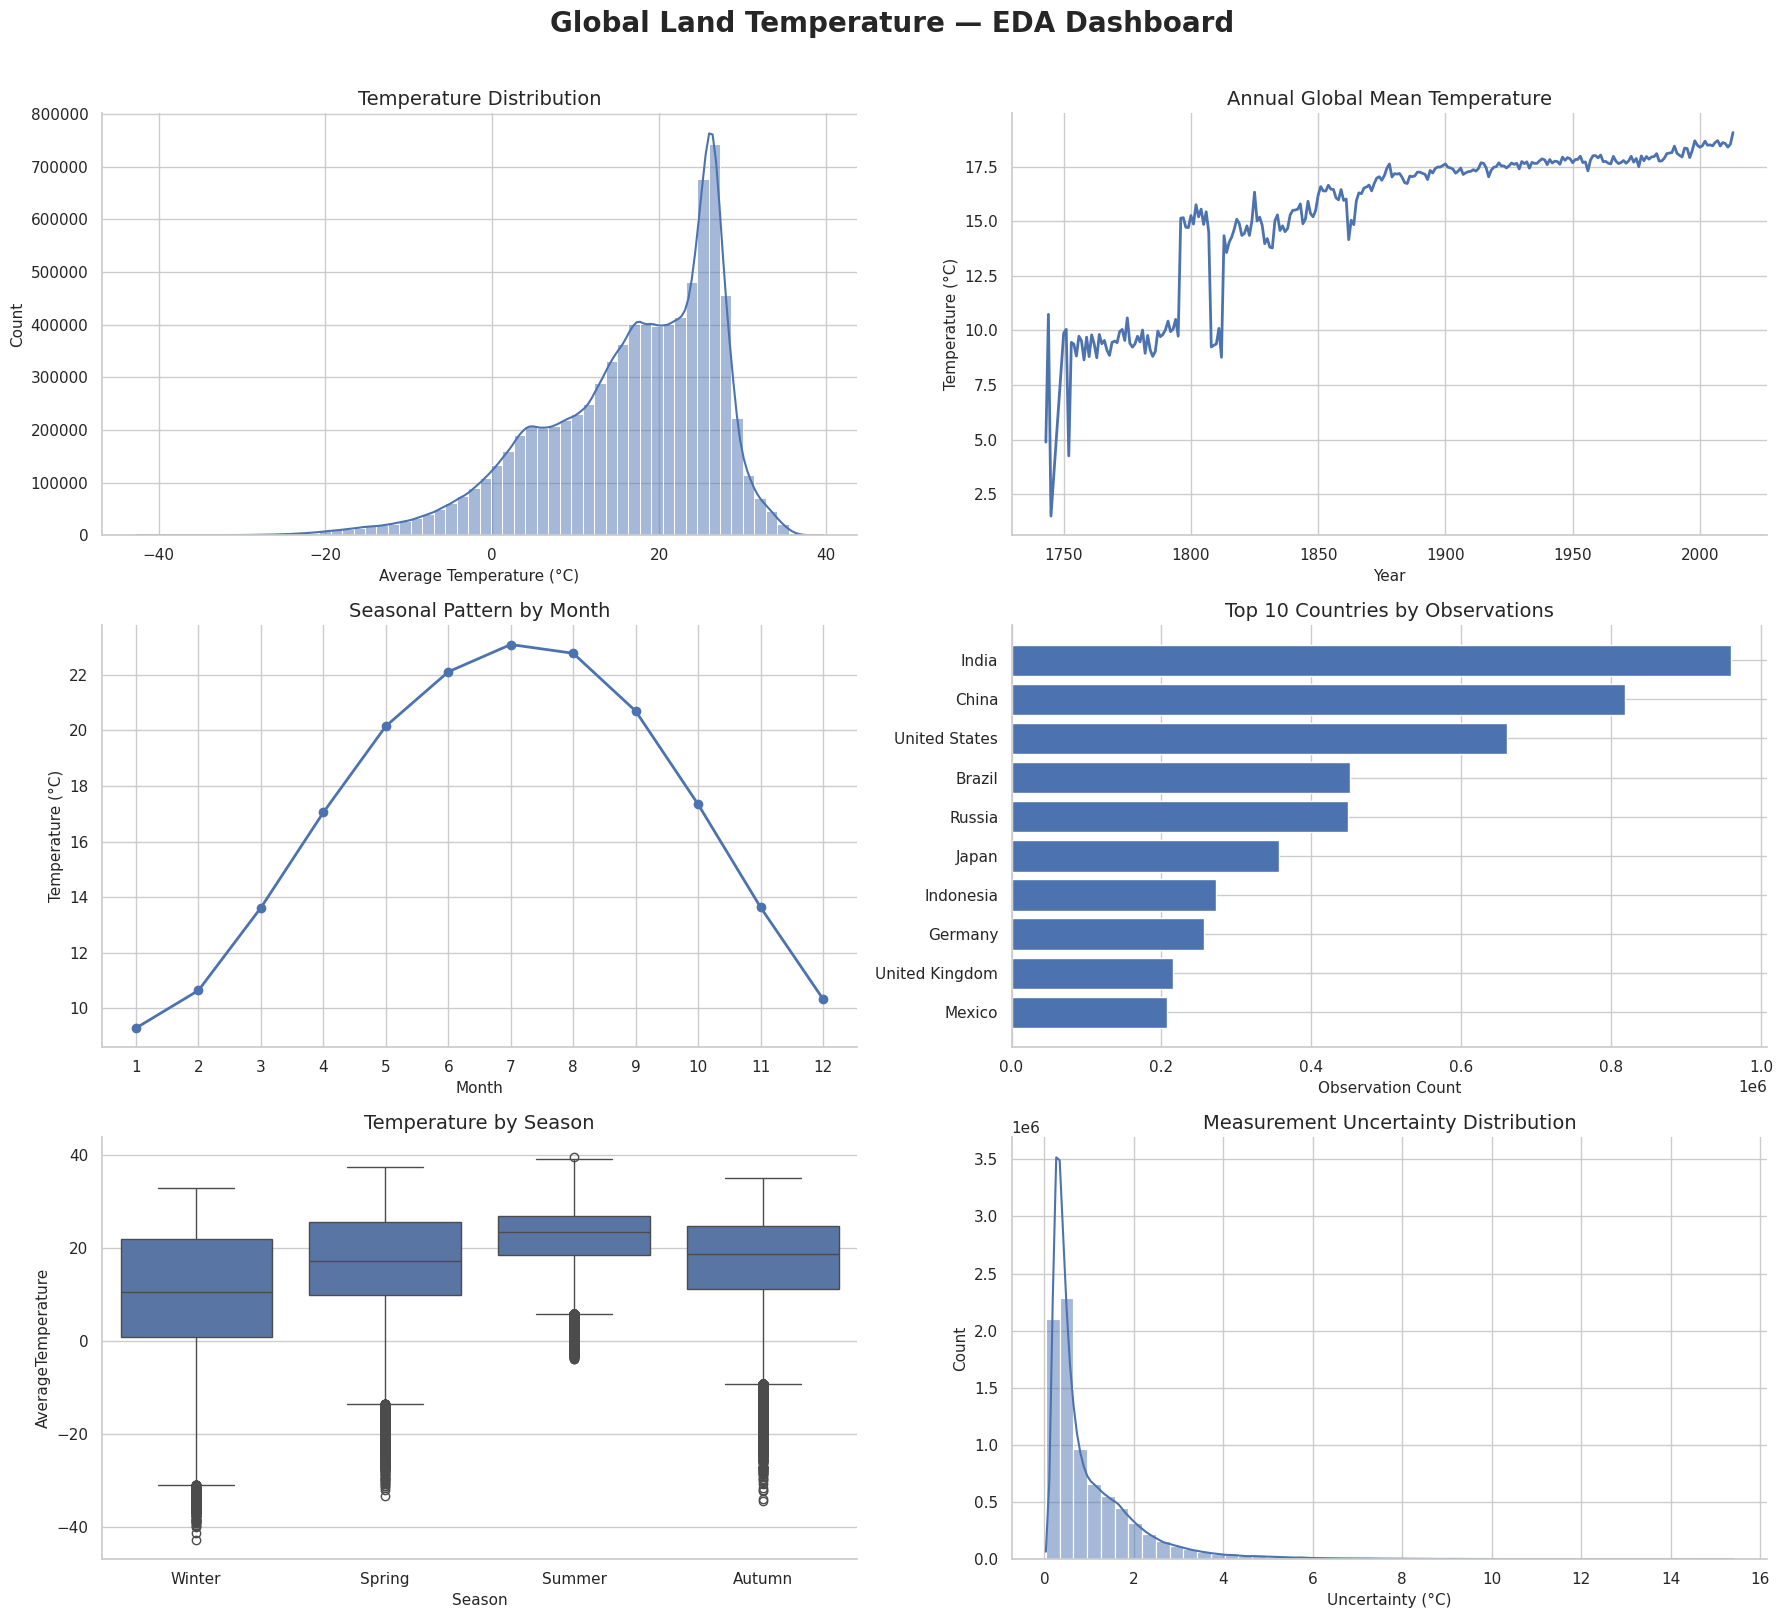

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle("Global Land Temperature — EDA Dashboard", fontsize=20, fontweight="bold", y=1.01)

sns.histplot(df["AverageTemperature"], bins=60, kde=True, ax=axes[0,0])
axes[0,0].set_title("Temperature Distribution")
axes[0,0].set_xlabel("Average Temperature (°C)")

annual = df.groupby("Year")["AverageTemperature"].mean()
axes[0,1].plot(annual.index, annual.values, linewidth=2)
axes[0,1].set_title("Annual Global Mean Temperature")
axes[0,1].set_xlabel("Year"); axes[0,1].set_ylabel("Temperature (°C)")

monthly = df.groupby("Month")["AverageTemperature"].mean()
axes[1,0].plot(monthly.index, monthly.values, marker="o", linewidth=2)
axes[1,0].set_xticks(range(1,13)); axes[1,0].set_title("Seasonal Pattern by Month")
axes[1,0].set_xlabel("Month"); axes[1,0].set_ylabel("Temperature (°C)")

top_countries = df["Country"].value_counts().head(10).sort_values()
axes[1,1].barh(top_countries.index, top_countries.values)
axes[1,1].set_title("Top 10 Countries by Observations")
axes[1,1].set_xlabel("Observation Count")

sns.boxplot(data=df, x="Season", y="AverageTemperature", order=["Winter","Spring","Summer","Autumn"], ax=axes[2,0])
axes[2,0].set_title("Temperature by Season")

sns.histplot(df["AverageTemperatureUncertainty"].dropna(), bins=50, kde=True, ax=axes[2,1])
axes[2,1].set_title("Measurement Uncertainty Distribution")
axes[2,1].set_xlabel("Uncertainty (°C)")

plt.tight_layout(); plt.show()

## 🌡️ Year × Month Temperature Heatmap

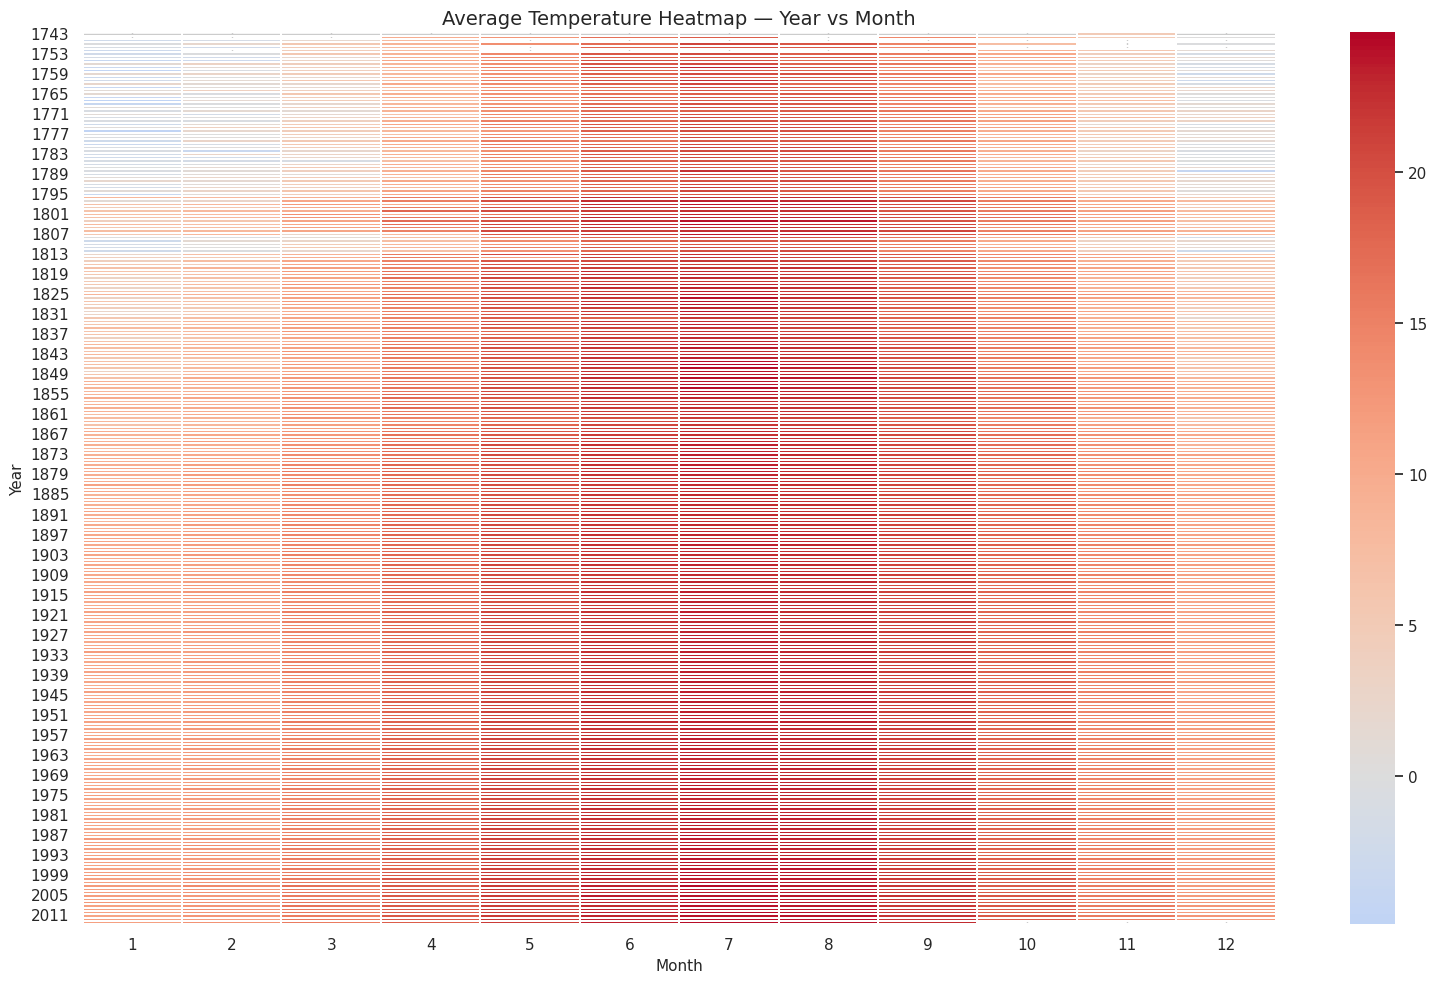

In [9]:
year_month = df.pivot_table(index="Year", columns="Month", values="AverageTemperature", aggfunc="mean")
plt.figure(figsize=(16,10))
sns.heatmap(year_month, cmap="coolwarm", center=0, linewidths=.05)
plt.title("Average Temperature Heatmap — Year vs Month")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout(); plt.show()

## 📈 Smoothed Long-Term Trend

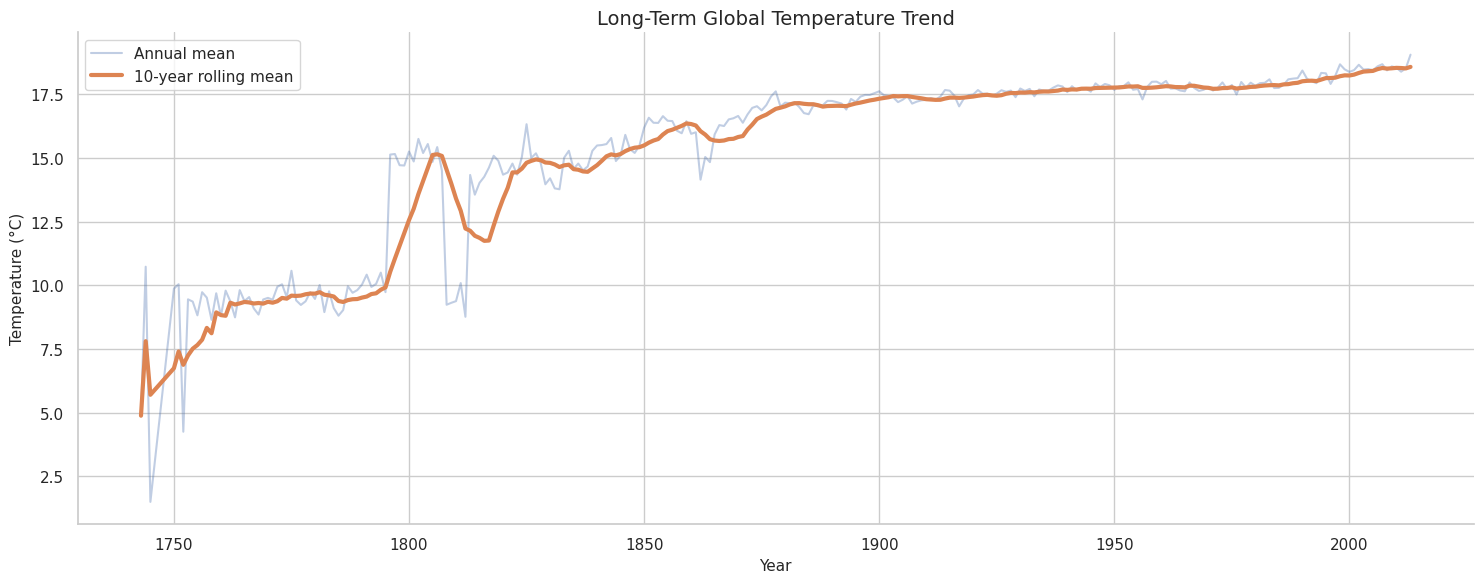

In [10]:
annual_df = df.groupby("Year", as_index=False)["AverageTemperature"].mean()
annual_df["Rolling10Y"] = annual_df["AverageTemperature"].rolling(10, min_periods=1).mean()
plt.figure(figsize=(15,6))
plt.plot(annual_df["Year"], annual_df["AverageTemperature"], alpha=.35, label="Annual mean")
plt.plot(annual_df["Year"], annual_df["Rolling10Y"], linewidth=3, label="10-year rolling mean")
plt.title("Long-Term Global Temperature Trend")
plt.xlabel("Year"); plt.ylabel("Temperature (°C)"); plt.legend()
plt.tight_layout(); plt.show()

## 🌍 Geographic Temperature Distribution

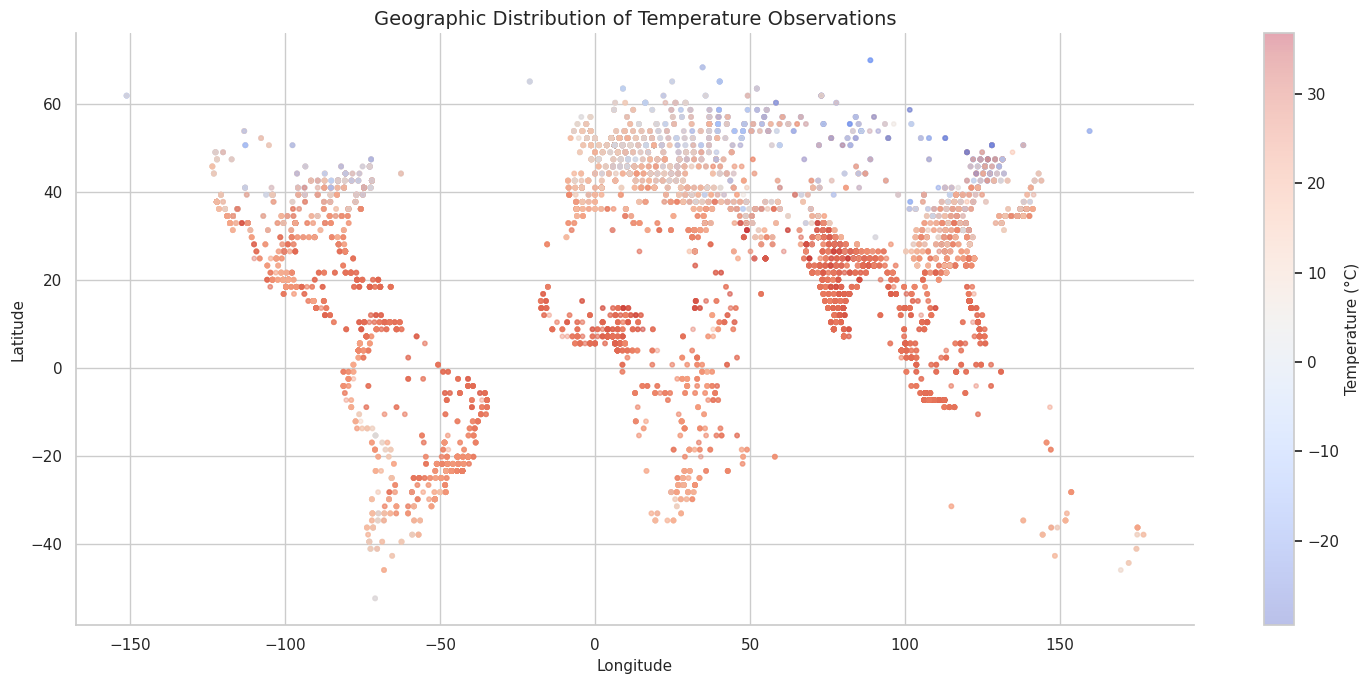

In [11]:
geo=df.dropna(subset=["LatitudeDecimal","LongitudeDecimal"]).sample(min(20000,len(df)), random_state=RANDOM_STATE)
plt.figure(figsize=(15,7))
sc=plt.scatter(geo["LongitudeDecimal"], geo["LatitudeDecimal"], c=geo["AverageTemperature"], s=10, alpha=.35, cmap="coolwarm")
plt.colorbar(sc,label="Temperature (°C)")
plt.title("Geographic Distribution of Temperature Observations")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

## 🔎 Correlation Analysis

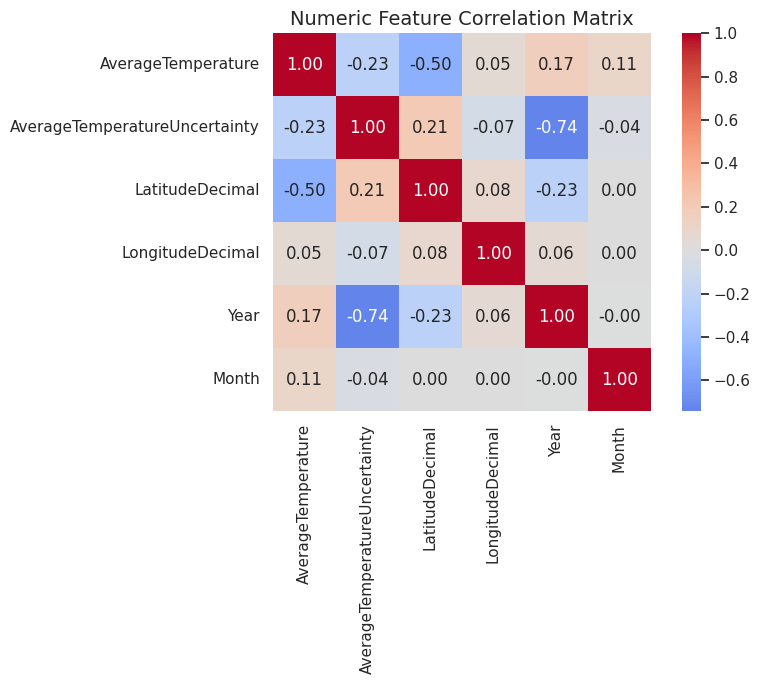

In [12]:
num_cols=["AverageTemperature","AverageTemperatureUncertainty","LatitudeDecimal","LongitudeDecimal","Year","Month"]
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout(); plt.show()

## 7. Global Long-Term Temperature Trend
This chart calculates the average of available city observations for each year. It is useful for exploratory analysis of long-term patterns.

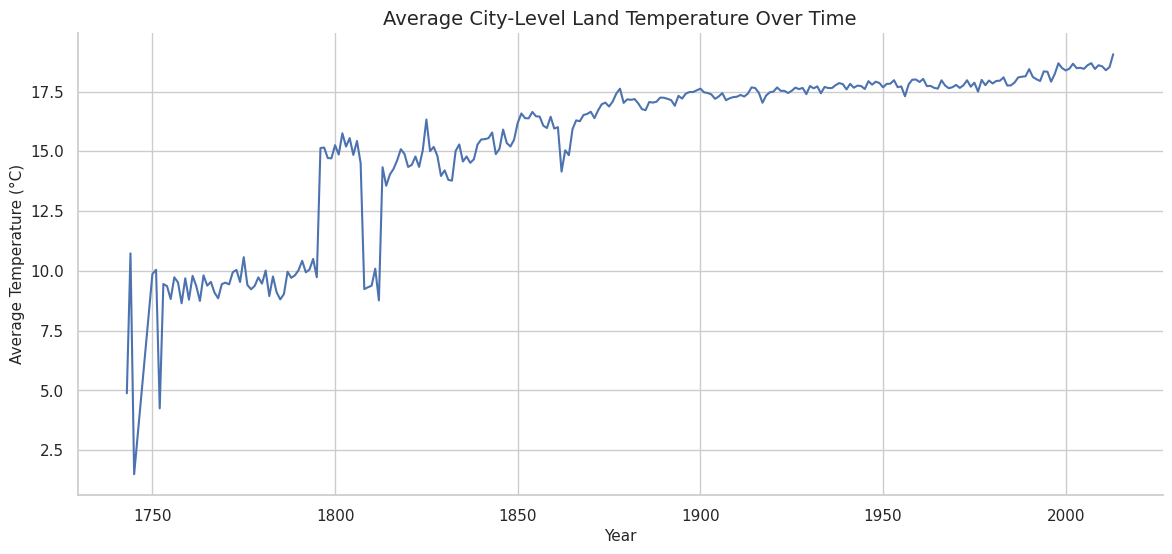

In [13]:
global_yearly = df.groupby("Year", as_index=False)["AverageTemperature"].mean()

plt.figure(figsize=(14, 6))
plt.plot(global_yearly["Year"], global_yearly["AverageTemperature"])
plt.title("Average City-Level Land Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.show()

## 8. Decade-Wise Temperature Trend
Decade averages smooth year-to-year variation and make broad trends easier to observe.

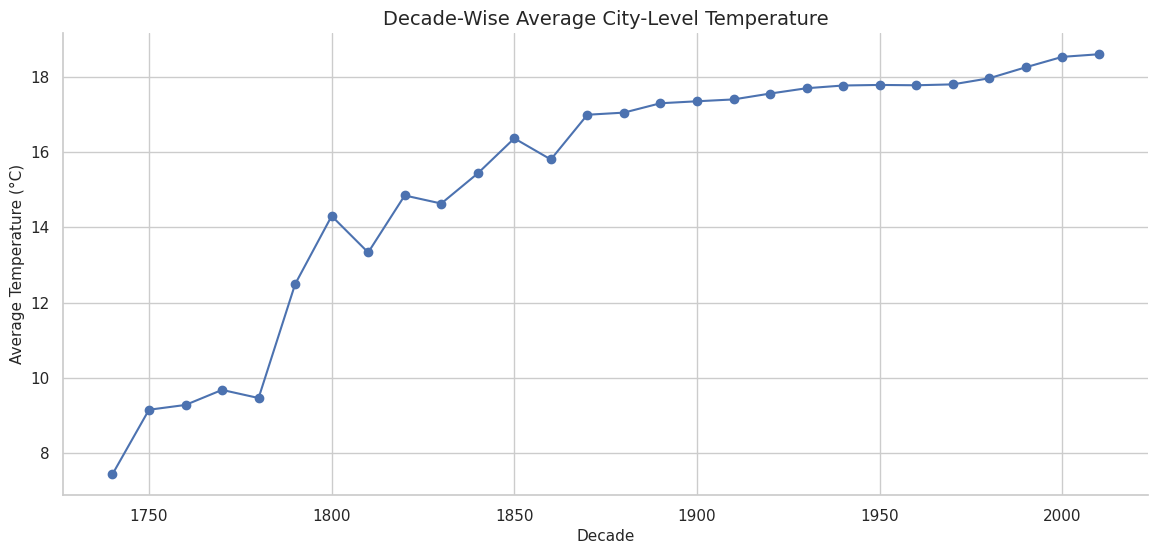

In [14]:
decade_trend = df.groupby("Decade", as_index=False)["AverageTemperature"].mean()

plt.figure(figsize=(14, 6))
plt.plot(decade_trend["Decade"], decade_trend["AverageTemperature"], marker="o")
plt.title("Decade-Wise Average City-Level Temperature")
plt.xlabel("Decade")
plt.ylabel("Average Temperature (°C)")
plt.show()

## 9. Missing-Data Analysis Over Time
This section examines how missing temperature measurements are distributed historically.

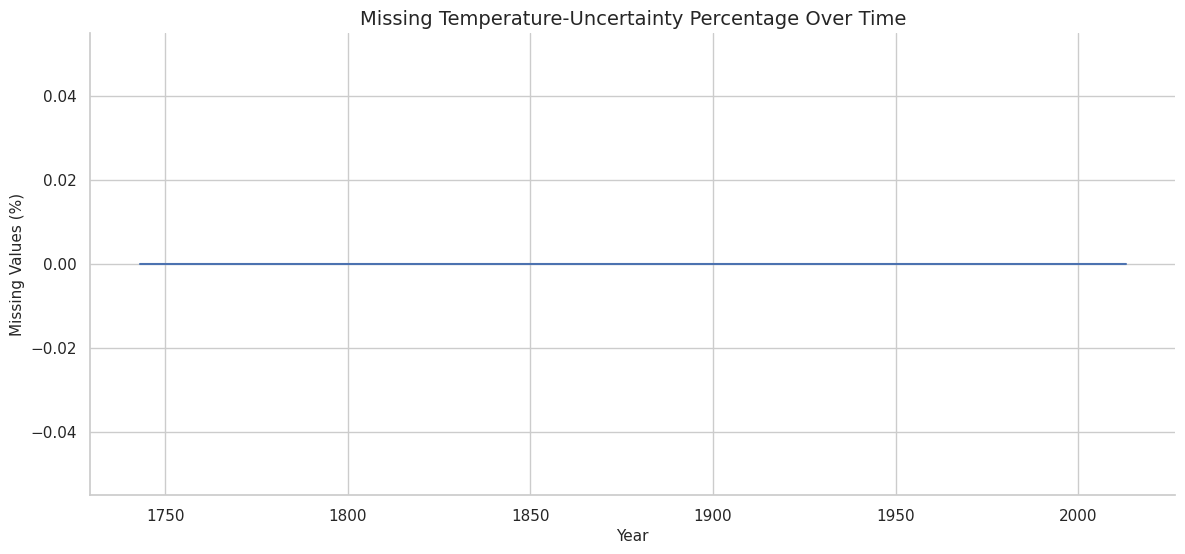

In [15]:
missing_over_time = (
    df.assign(IsMissingUncertainty=df["AverageTemperatureUncertainty"].isna())
      .groupby("Year", as_index=False)["IsMissingUncertainty"]
      .mean()
)

plt.figure(figsize=(14, 6))
plt.plot(missing_over_time["Year"], missing_over_time["IsMissingUncertainty"] * 100)
plt.title("Missing Temperature-Uncertainty Percentage Over Time")
plt.xlabel("Year")
plt.ylabel("Missing Values (%)")
plt.show()

## 10. Country-Level Analysis
Countries are ranked using their historical mean city-level temperature. Observation counts are also retained.

In [16]:
country_summary = (
    df.groupby("Country")["AverageTemperature"]
      .agg(AverageTemperature="mean", Observations="count")
      .sort_values("AverageTemperature")
)

print("❄️ 10 Coldest Countries")
display(country_summary.head(10).round(3))

print("🔥 10 Warmest Countries")
display(country_summary.tail(10).sort_values("AverageTemperature", ascending=False).round(3))

❄️ 10 Coldest Countries


,AverageTemperature,Observations
Country,,
Mongolia,-3.365,2316
Iceland,1.500,3057
Russia,3.347,448663
Norway,3.613,12664
Finland,3.712,15830
Kazakhstan,4.340,35613
Estonia,4.696,6332
Canada,4.900,71444
Latvia,5.387,6332


🔥 10 Warmest Countries


,AverageTemperature,Observations
Country,,
Djibouti,29.153,1658
Niger,28.146,5206
Sudan,28.073,17160
Burkina Faso,27.815,3704
Mali,27.590,5619
Chad,27.190,3470
Guinea Bissau,27.057,1871
Mauritania,27.022,1925
Benin,26.976,10560


## 11. City-Level Analysis
Cities are ranked by historical mean temperature.

In [17]:
city_summary = (
    df.groupby(["City", "Country"])["AverageTemperature"]
      .agg(AverageTemperature="mean", Observations="count")
      .sort_values("AverageTemperature")
)

print("❄️ 10 Coldest Cities")
display(city_summary.head(10).round(3))

print("🔥 10 Warmest Cities")
display(city_summary.tail(10).sort_values("AverageTemperature", ascending=False).round(3))

❄️ 10 Coldest Cities


,,AverageTemperature,Observations
City,Country,,
Norilsk,Russia,-11.855,2317
Kyzyl,Russia,-6.222,2317
Chita,Russia,-4.360,2317
Ust Ilimsk,Russia,-3.997,2317
Nefteyugansk,Russia,-3.538,2419
Surgut,Russia,-3.538,2419
Ulaanbaatar,Mongolia,-3.365,2316
Ulan Ude,Russia,-3.180,2317
Bratsk,Russia,-2.818,2317


🔥 10 Warmest Cities


,,AverageTemperature,Observations
City,Country,,
Jibuti,Djibouti,29.153,1658
Khartoum,Sudan,29.081,1768
Umm Durman,Sudan,29.081,1768
Niamey,Niger,29.063,1764
Kassala,Sudan,28.939,1745
Mopti,Mali,28.784,1877
Kusti,Sudan,28.598,1679
Rabak,Sudan,28.598,1679
Ambattur,India,28.418,2508


## 12. Seasonal Temperature Pattern
Average temperature is calculated for each month to visualize seasonal behavior.

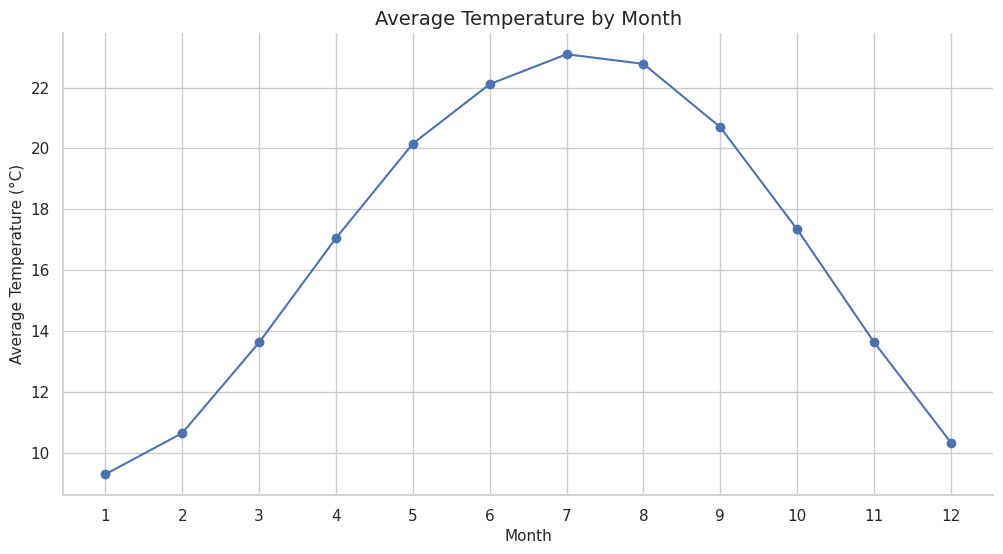

In [18]:
monthly_pattern = df.groupby("Month", as_index=False)["AverageTemperature"].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_pattern["Month"], monthly_pattern["AverageTemperature"], marker="o")
plt.xticks(range(1, 13))
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.show()

## 13. Select a City for Forecasting
To provide a reproducible model without requiring manual input, the notebook automatically selects the city with the largest number of cleaned observations.

In [19]:
city_counts=df.groupby(["City","Country"]).size().sort_values(ascending=False)
SELECTED_CITY, SELECTED_COUNTRY = city_counts.index[0]

city_df=(df[(df["City"]==SELECTED_CITY)&(df["Country"]==SELECTED_COUNTRY)]
          .groupby("dt",as_index=False)["AverageTemperature"].mean()
          .sort_values("dt"))
city_df=city_df.set_index("dt").asfreq("MS")
city_df["AverageTemperature"]=city_df["AverageTemperature"].interpolate(limit_direction="both")
city_df=city_df.reset_index()
city_df["Year"]=city_df["dt"].dt.year
city_df["Month"]=city_df["dt"].dt.month
print("Selected city:",SELECTED_CITY,",",SELECTED_COUNTRY)
print("Monthly observations:",len(city_df))
display(city_df.head())

Selected city: Springfield , United States
Monthly observations: 3239


,dt,AverageTemperature,Year,Month
0,1743-11-01,2.9770,1743,11
1,1743-12-01,4.4988,1743,12
2,1744-01-01,6.0206,1744,1
3,1744-02-01,7.5424,1744,2
4,1744-03-01,9.0642,1744,3


## 14. Create Time-Series Features
Lag features represent earlier monthly temperatures. The rolling mean summarizes the previous 12 months. Only rows with complete model features are retained.

In [20]:
model_df=city_df.copy()
for lag in [1,3,6,12]:
    model_df[f"Lag{lag}"]=model_df["AverageTemperature"].shift(lag)
model_df["RollingMean3"]=model_df["AverageTemperature"].shift(1).rolling(3).mean()
model_df["RollingMean12"]=model_df["AverageTemperature"].shift(1).rolling(12).mean()
model_df["MonthSin"]=np.sin(2*np.pi*model_df["Month"]/12)
model_df["MonthCos"]=np.cos(2*np.pi*model_df["Month"]/12)
model_df=model_df.dropna().reset_index(drop=True)
feature_cols=["Year","Month","Lag1","Lag3","Lag6","Lag12","RollingMean3","RollingMean12","MonthSin","MonthCos"]
target_col="AverageTemperature"
print("Modeling rows:",len(model_df)); display(model_df.head())

Modeling rows: 3227


,dt,AverageTemperature,Year,Month,Lag1,Lag3,Lag6,Lag12,RollingMean3,RollingMean12,MonthSin,MonthCos
0,1744-11-01,3.0735,1744,11,9.0815,19.0475,15.8360,2.9770,14.528667,12.011625,-5.000000e-01,8.660254e-01
1,1744-12-01,-3.2515,1744,12,3.0735,15.4570,21.3905,4.4988,9.204000,12.019667,-2.449294e-16,1.000000e+00
2,1745-01-01,-3.7520,1745,1,-3.2515,9.0815,22.6380,6.0206,2.967833,11.373808,5.000000e-01,8.660254e-01
3,1745-02-01,-3.0105,1745,2,-3.7520,3.0735,19.0475,7.5424,-1.310000,10.559425,8.660254e-01,5.000000e-01
4,1745-03-01,1.5215,1745,3,-3.0105,-3.2515,15.4570,9.0642,-3.338000,9.680017,1.000000e+00,6.123234e-17


## 15. Chronological Train-Test Split
The earliest 80% of observations are used for training and the most recent 20% for testing. This preserves the time order.

In [21]:
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Test period:", test_df["dt"].min().date(), "to", test_df["dt"].max().date())

Training rows: 2581
Testing rows: 646
Test period: 1959-12-01 to 2013-09-01


## 16. Train and Compare Models
Three models are trained: Linear Regression as a baseline, Random Forest as a non-linear ensemble, and Histogram Gradient Boosting as an advanced boosting model.

In [22]:
models={
    "Linear Regression":LinearRegression(),
    "Random Forest":RandomForestRegressor(n_estimators=250,max_depth=14,min_samples_leaf=2,random_state=RANDOM_STATE,n_jobs=-1),
    "Histogram Gradient Boosting":HistGradientBoostingRegressor(max_iter=250,learning_rate=.05,max_leaf_nodes=31,random_state=RANDOM_STATE)
}
results=[]; predictions={}
for name,model in models.items():
    print("Training",name)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    predictions[name]=pred
    results.append({"Model":name,"MAE":mean_absolute_error(y_test,pred),"RMSE":rmse(y_test,pred),"R2":r2_score(y_test,pred)})
results_df=pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.round(4))

Training Linear Regression
Training Random Forest
Training Histogram Gradient Boosting


,Model,MAE,RMSE,R2
0,Random Forest,1.3625,1.8106,0.9638
1,Histogram Gradient Boosting,1.4363,1.9076,0.9598
2,Linear Regression,1.4813,1.9480,0.9581


## 17. Best Model Evaluation
The model with the lowest RMSE is selected as the best-performing model.

In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_prediction = predictions[best_model_name]

print("🏆 Best Model:", best_model_name)
print("MAE :", round(results_df.iloc[0]["MAE"], 4))
print("RMSE:", round(results_df.iloc[0]["RMSE"], 4))
print("R²  :", round(results_df.iloc[0]["R2"], 4))

🏆 Best Model: Random Forest
MAE : 1.3625
RMSE: 1.8106
R²  : 0.9638


## 18. Actual vs Predicted Temperatures
The chart compares actual temperatures with predictions during the held-out test period.

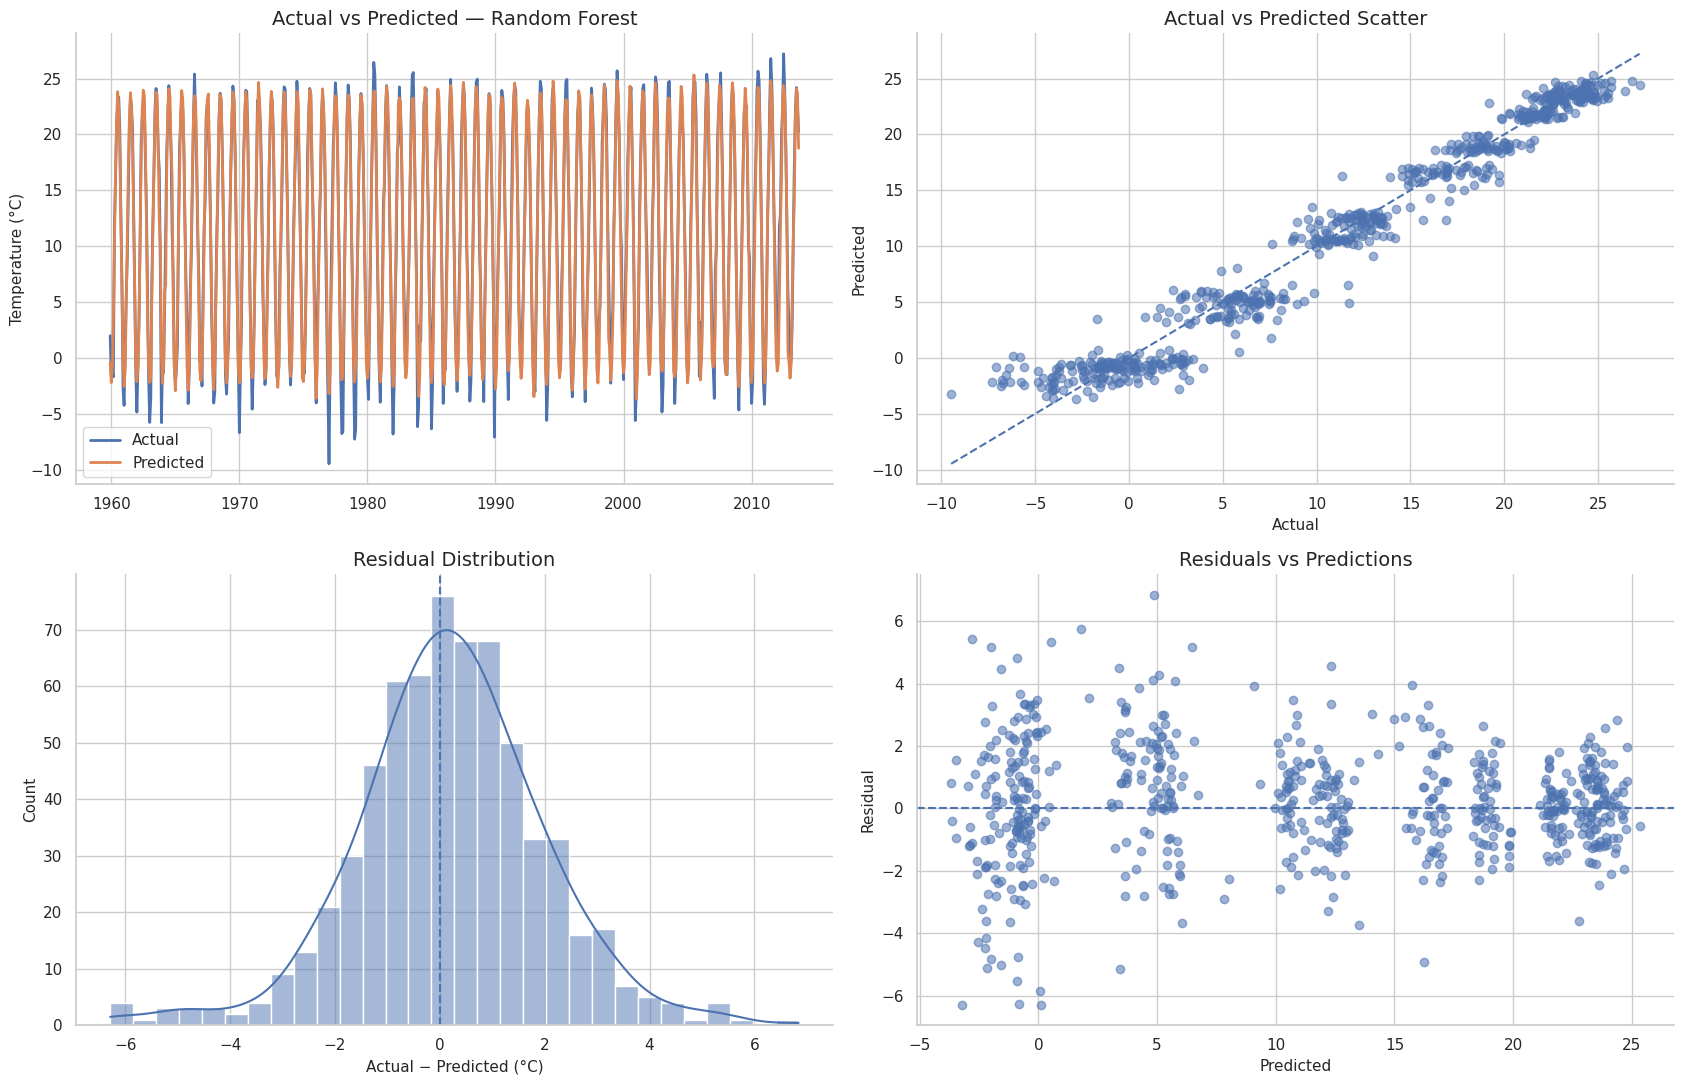

In [24]:
residuals=y_test.to_numpy()-best_prediction
fig,axes=plt.subplots(2,2,figsize=(17,11))
axes[0,0].plot(test_df["dt"],y_test.to_numpy(),label="Actual",linewidth=2)
axes[0,0].plot(test_df["dt"],best_prediction,label="Predicted",linewidth=2)
axes[0,0].set_title(f"Actual vs Predicted — {best_model_name}"); axes[0,0].set_ylabel("Temperature (°C)"); axes[0,0].legend()
axes[0,1].scatter(y_test,best_prediction,alpha=.55)
lims=[min(y_test.min(),best_prediction.min()),max(y_test.max(),best_prediction.max())]
axes[0,1].plot(lims,lims,"--"); axes[0,1].set_title("Actual vs Predicted Scatter"); axes[0,1].set_xlabel("Actual"); axes[0,1].set_ylabel("Predicted")
sns.histplot(residuals,bins=30,kde=True,ax=axes[1,0]); axes[1,0].axvline(0,linestyle="--"); axes[1,0].set_title("Residual Distribution"); axes[1,0].set_xlabel("Actual − Predicted (°C)")
axes[1,1].scatter(best_prediction,residuals,alpha=.55); axes[1,1].axhline(0,linestyle="--"); axes[1,1].set_title("Residuals vs Predictions"); axes[1,1].set_xlabel("Predicted"); axes[1,1].set_ylabel("Residual")
plt.tight_layout(); plt.show()

## 19. Residual Analysis
Residuals are calculated as Actual minus Predicted. Their distribution helps identify systematic prediction error.

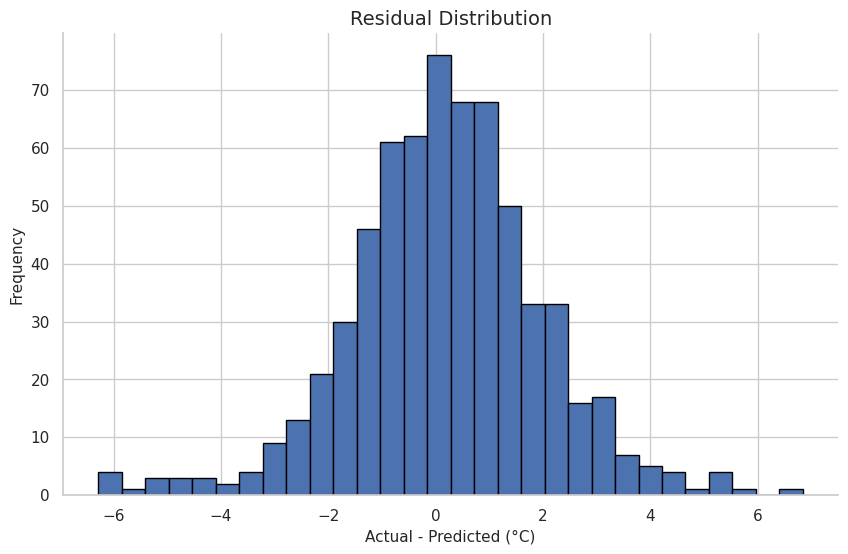

Mean residual: 0.1904
Residual standard deviation: 1.8006


In [25]:
residuals = y_test.to_numpy() - best_prediction

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor="black")
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted (°C)")
plt.ylabel("Frequency")
plt.show()

print("Mean residual:", round(residuals.mean(), 4))
print("Residual standard deviation:", round(residuals.std(), 4))

## 🔍 Feature Importance

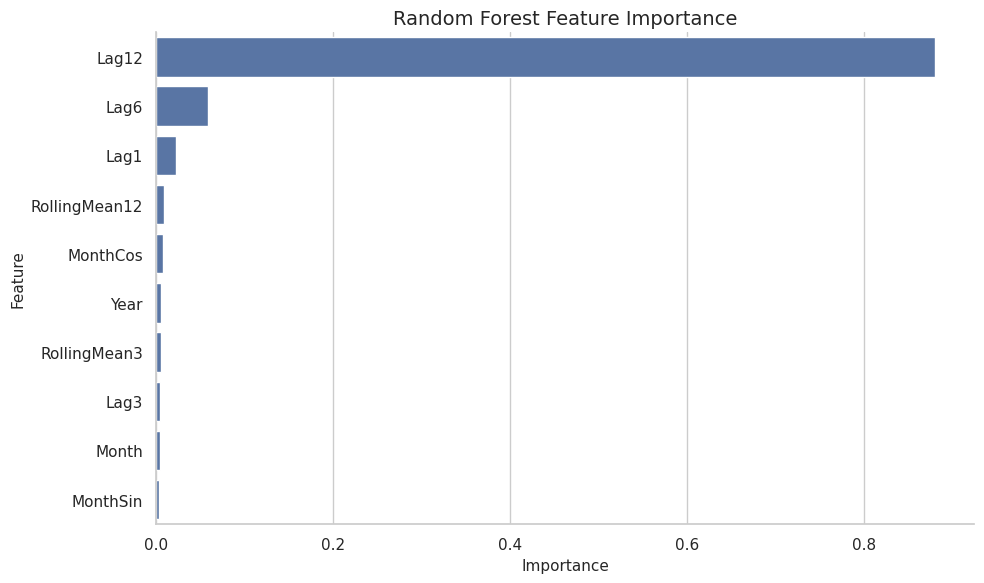

,Importance
Lag12,0.8805
Lag6,0.0581
Lag1,0.0226
RollingMean12,0.0088
MonthCos,0.0078
Year,0.0056
RollingMean3,0.0053
Lag3,0.0043
Month,0.0040
MonthSin,0.0032


In [26]:
rf_imp=pd.Series(models["Random Forest"].feature_importances_,index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6)); sns.barplot(x=rf_imp.values,y=rf_imp.index)
plt.title("Random Forest Feature Importance"); plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout(); plt.show(); display(rf_imp.to_frame("Importance").round(4))

## 🧠 Deep Learning — LSTM Time-Series Forecasting

The LSTM uses the previous 12 months as a sequence and evaluates only the chronological test period. Scaling is fitted on training data to avoid leakage.

Epoch 1/25


2026-08-24 06:59:47.512916: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0880 - mae: 0.2499 - val_loss: 0.0555 - val_mae: 0.2088
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0416 - mae: 0.1699 - val_loss: 0.0039 - val_mae: 0.0492
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0126 - mae: 0.0864 - val_loss: 0.0030 - val_mae: 0.0431
Epoch 4/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0094 - mae: 0.0739 - val_loss: 0.0027 - val_mae: 0.0409
Epoch 5/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0093 - mae: 0.0742 - val_loss: 0.0057 - val_mae: 0.0646
Epoch 6/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0080 - mae: 0.0675 - val_loss: 0.0034 - val_mae: 0.0475
Epoch 7/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0073 - mae: 0.0642 - val_loss: 0.0045 - val_mae: 0.0562
Epoch 8/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0067 - mae: 0.0620 - val_loss: 0.0049 - val_mae: 0.0578
Epoch 9/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0067 - mae: 0.

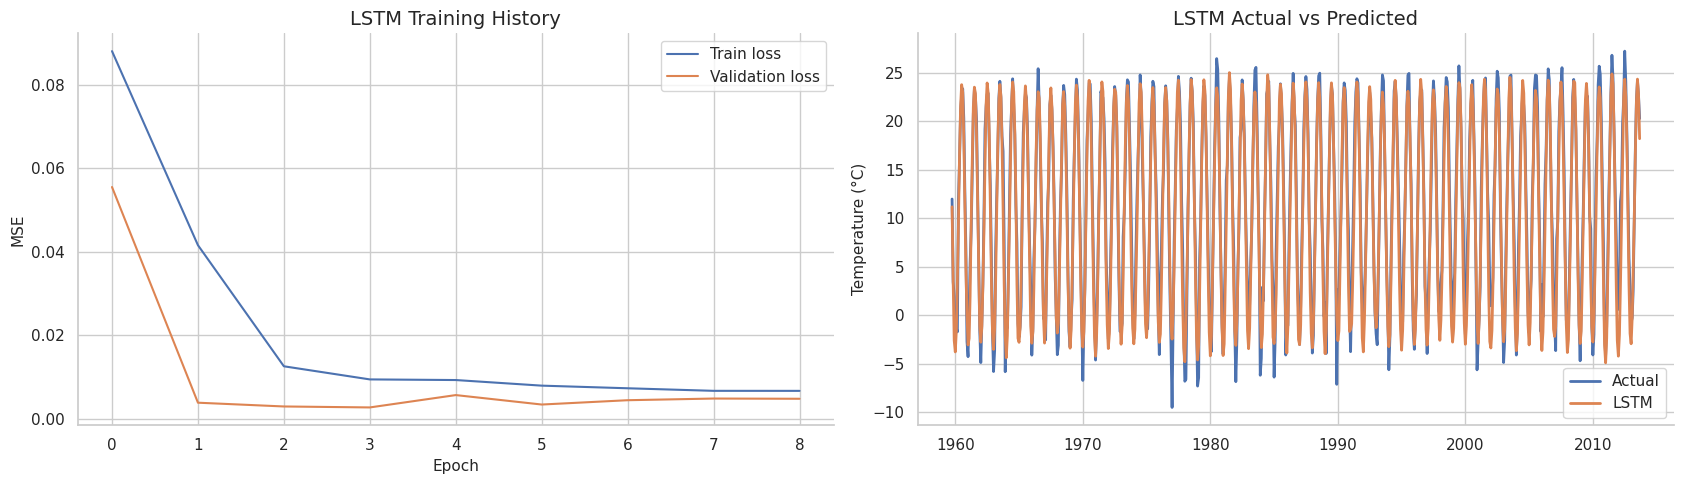

  Model     MAE    RMSE      R2
0  LSTM  1.6627  2.1625  0.9482


In [27]:
RUN_DEEP_LEARNING=True
try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(RANDOM_STATE)
    TF_AVAILABLE=True
except Exception as e:
    TF_AVAILABLE=False
    print("TensorFlow unavailable — LSTM will be skipped:",e)

lstm_results=None; lstm_model=None; lstm_predictions=None
if TF_AVAILABLE:
    values=city_df["AverageTemperature"].values.reshape(-1,1)
    raw_split=int(len(values)*.80)
    scaler=MinMaxScaler(); scaler.fit(values[:raw_split])
    scaled=scaler.transform(values)
    seq_len=12
    Xs=[]; ys=[]; pos=[]
    for i in range(seq_len,len(scaled)):
        Xs.append(scaled[i-seq_len:i]); ys.append(scaled[i]); pos.append(i)
    Xs=np.array(Xs); ys=np.array(ys); pos=np.array(pos)
    train_mask=pos<raw_split; test_mask=pos>=raw_split
    Xtr,ytr=Xs[train_mask],ys[train_mask]; Xte,yte=Xs[test_mask],ys[test_mask]
    lstm_model=Sequential([LSTM(64,return_sequences=True,input_shape=(seq_len,1)),Dropout(.2),LSTM(32),Dropout(.2),Dense(16,activation="relu"),Dense(1)])
    lstm_model.compile(optimizer="adam",loss="mse",metrics=["mae"])
    es=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
    history=lstm_model.fit(Xtr,ytr,validation_split=.15,epochs=25,batch_size=32,callbacks=[es],verbose=1)
    pred_scaled=lstm_model.predict(Xte,verbose=0)
    lstm_predictions=scaler.inverse_transform(pred_scaled).ravel()
    y_lstm=scaler.inverse_transform(yte).ravel()
    lstm_results={"Model":"LSTM","MAE":mean_absolute_error(y_lstm,lstm_predictions),"RMSE":rmse(y_lstm,lstm_predictions),"R2":r2_score(y_lstm,lstm_predictions)}
    fig,axes=plt.subplots(1,2,figsize=(17,5))
    axes[0].plot(history.history["loss"],label="Train loss"); axes[0].plot(history.history["val_loss"],label="Validation loss"); axes[0].set_title("LSTM Training History"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()
    dates=city_df["dt"].iloc[pos[test_mask]]
    axes[1].plot(dates,y_lstm,label="Actual",linewidth=2); axes[1].plot(dates,lstm_predictions,label="LSTM",linewidth=2); axes[1].set_title("LSTM Actual vs Predicted"); axes[1].set_ylabel("Temperature (°C)"); axes[1].legend()
    plt.tight_layout(); plt.show()
    print(pd.DataFrame([lstm_results]).round(4))
else:
    print("Set up TensorFlow to enable the deep-learning section.")

## 🥇 Final Model Comparison

,Model,MAE,RMSE,R2
0,Random Forest,1.3625,1.8106,0.9638
1,Histogram Gradient Boosting,1.4363,1.9076,0.9598
2,Linear Regression,1.4813,1.9480,0.9581
3,LSTM,1.6627,2.1625,0.9482


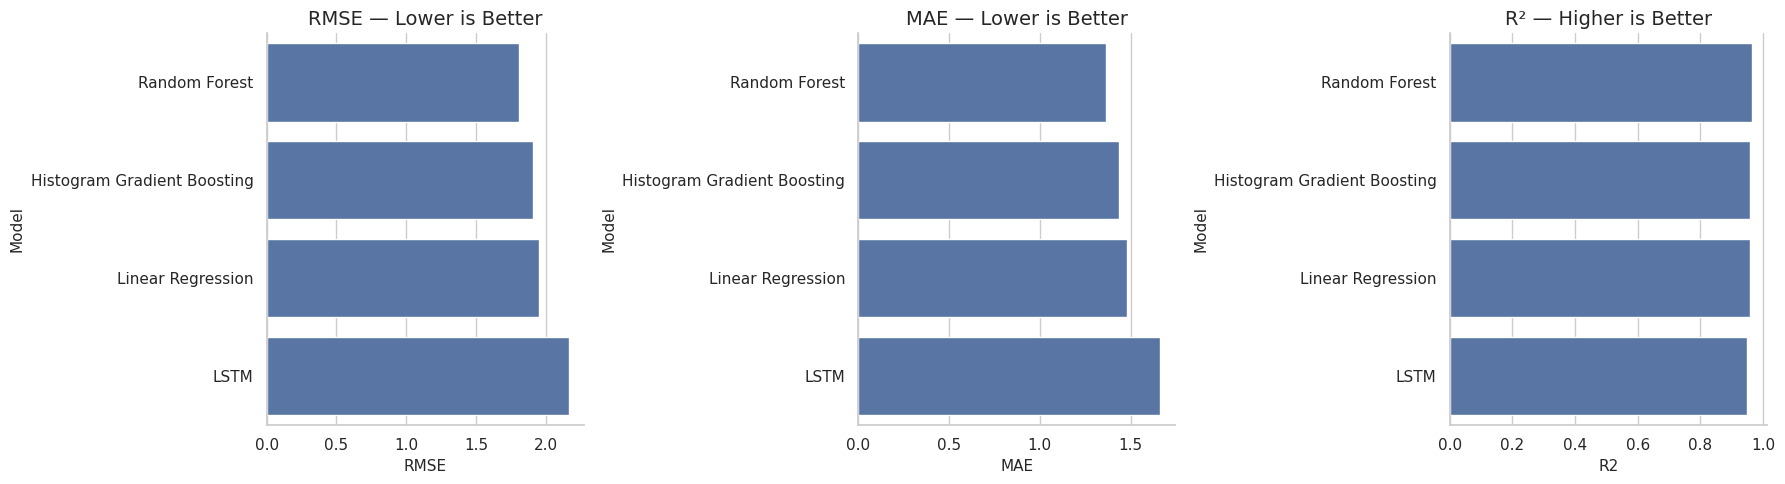

🏆 Best overall model: Random Forest | RMSE=1.8106 | MAE=1.3625 | R²=0.9638


In [28]:
comparison=results_df.copy()
if lstm_results is not None:
    comparison=pd.concat([comparison,pd.DataFrame([lstm_results])],ignore_index=True)
comparison=comparison.sort_values("RMSE").reset_index(drop=True)
display(comparison.round(4))
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.barplot(data=comparison,x="RMSE",y="Model",ax=axes[0]); axes[0].set_title("RMSE — Lower is Better")
sns.barplot(data=comparison,x="MAE",y="Model",ax=axes[1]); axes[1].set_title("MAE — Lower is Better")
sns.barplot(data=comparison,x="R2",y="Model",ax=axes[2]); axes[2].set_title("R² — Higher is Better")
plt.tight_layout(); plt.show()
final_best=comparison.iloc[0]
print(f"🏆 Best overall model: {final_best['Model']} | RMSE={final_best['RMSE']:.4f} | MAE={final_best['MAE']:.4f} | R²={final_best['R2']:.4f}")

## 20. One-Step-Ahead Forecast
The latest observations create the lag and rolling features needed to forecast the month after the last available record.

In [29]:
last_date=city_df["dt"].max(); next_date=last_date+pd.DateOffset(months=1)
history_values=city_df["AverageTemperature"].dropna().reset_index(drop=True)
forecast_input=pd.DataFrame([{
    "Year":next_date.year,"Month":next_date.month,"Lag1":history_values.iloc[-1],"Lag3":history_values.iloc[-3],"Lag6":history_values.iloc[-6],"Lag12":history_values.iloc[-12],
    "RollingMean3":history_values.iloc[-3:].mean(),"RollingMean12":history_values.iloc[-12:].mean(),
    "MonthSin":np.sin(2*np.pi*next_date.month/12),"MonthCos":np.cos(2*np.pi*next_date.month/12)
}])
ml_forecast=float(best_model.predict(forecast_input)[0])
lstm_forecast=None
if lstm_results is not None:
    last_seq=scaler.transform(history_values.to_numpy().reshape(-1,1))[-12:].reshape(1,12,1)
    lstm_forecast=float(scaler.inverse_transform(lstm_model.predict(last_seq,verbose=0))[0,0])
print("🔮 NEXT-MONTH FORECAST")
print("City:",SELECTED_CITY,",",SELECTED_COUNTRY)
print("Forecast month:",next_date.strftime("%B %Y"))
print(f"Best ML forecast: {ml_forecast:.2f} °C")
if lstm_forecast is not None: print(f"LSTM forecast: {lstm_forecast:.2f} °C")

🔮 NEXT-MONTH FORECAST
City: Springfield , United States
Forecast month: October 2013
Best ML forecast: 12.22 °C
LSTM forecast: 11.94 °C


## 21. Final Project Summary
This cell automatically summarizes the results generated by the analysis.

In [30]:
coldest_city = city_summary.index[0]
warmest_city = city_summary.index[-1]

print("=" * 65)
print("GLOBAL LAND TEMPERATURE ANALYSIS & FORECASTING")
print("=" * 65)
print(f"Records analyzed: {len(df):,}")
print(f"Date range: {df['dt'].min().date()} to {df['dt'].max().date()}")
print(f"Cities: {df['City'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Coldest city: {coldest_city[0]}, {coldest_city[1]}")
print(f"Warmest city: {warmest_city[0]}, {warmest_city[1]}")
print(f"Forecasting city: {SELECTED_CITY}")
print(f"Best model: {best_model_name}")
print(f"Best RMSE: {results_df.iloc[0]['RMSE']:.4f} °C")
print(f"Forecast: {forecast:.2f} °C for {next_date.strftime('%B %Y')}")

GLOBAL LAND TEMPERATURE ANALYSIS & FORECASTING
Records analyzed: 8,235,082
Date range: 1743-11-01 to 2013-09-01
Cities: 3,448
Countries: 159
Coldest city: Norilsk, Russia
Warmest city: Jibuti, Djibouti
Forecasting city: Springfield
Best model: Random Forest
Best RMSE: 1.8106 °C


NameError: name 'forecast' is not defined

## 22. Conclusion

This Kaggle-ready notebook completes the required project pipeline:

### **Load → Clean → Explore → Engineer Features → Train Models → Evaluate → Forecast**

The notebook uses chronological evaluation for time-series data and compares a baseline regression model with advanced machine-learning models. The final section produces a one-step-ahead forecast using the best model.

In [31]:
import joblib

joblib.dump(model, 'temperature_model.pkl')

['temperature_model.pkl']